In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("libraries imported successfully.")

libraries imported successfully.


In [3]:
# ============================================================
# Defining the 2D Reservoir Grid
# ============================================================

Nx = 51
Ny = 51

Lx = 1.0
Ly = 1.0

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

print("Number of x points:", Nx)
print("Number of y points:", Ny)
print("dx:", dx)
print("dy:", dy)

Number of x points: 51
Number of y points: 51
dx: 0.02
dy: 0.02


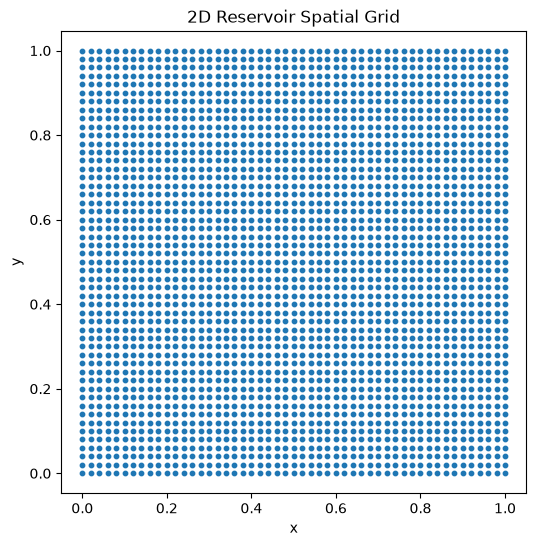

In [4]:
# ============================================================
# Visualize and Save the 2D Reservoir Grid
# ============================================================

X, Y = np.meshgrid(x, y)

plt.figure(figsize=(6, 6))

plt.scatter(X, Y, s=10)

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Reservoir Spatial Grid")
plt.axis("equal")

plt.savefig("../results/2d_reservoir_grid.png", dpi=300, bbox_inches="tight")

plt.show()

In [5]:
# ============================================================
# Define the Initial Pressure Field
# ============================================================

pressure_initial = np.sin(np.pi * X) * np.sin(np.pi * Y)

print("Initial pressure at center:", pressure_initial[Ny // 2, Nx // 2])
print("Initial pressure at corner:", pressure_initial[0, 0])

Initial pressure at center: 1.0
Initial pressure at corner: 0.0


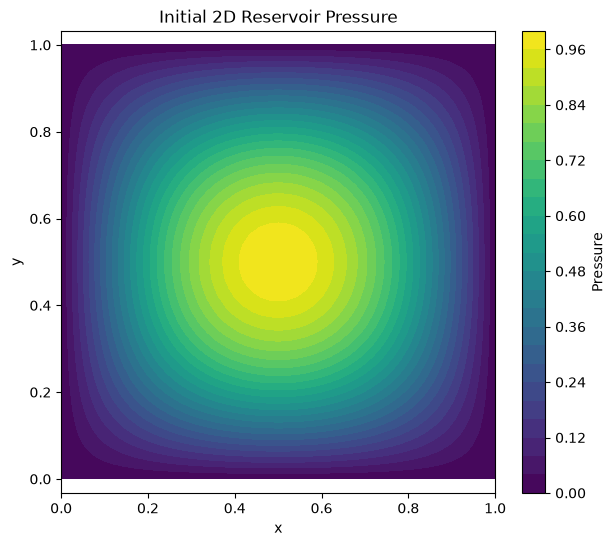

In [6]:
# ============================================================
# Plot and Save the Initial 2D Pressure Field
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(X, Y, pressure_initial, levels=30)

plt.colorbar(label="Pressure")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial 2D Reservoir Pressure")
plt.axis("equal")

plt.savefig(
    "../results/2d_initial_pressure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# ============================================================
# Define the Time Grid
# ============================================================

alpha = 0.1

T_max = 1.0
dt = 0.00004

Nt = int(T_max / dt) + 1

time = np.linspace(0, T_max, Nt)

print("Diffusivity alpha:", alpha)
print("Time step dt:", dt)
print("Number of time steps:", Nt)
print("Final simulation time:", time[-1])

Diffusivity alpha: 0.1
Time step dt: 4e-05
Number of time steps: 25000
Final simulation time: 1.0


In [8]:
# ============================================================
# Calculate the Maximum Stable Timestep for 2D
# ============================================================

dt_max = 1 / (
    2 * alpha * (
        1 / dx**2 +
        1 / dy**2
    )
)

print("Maximum stable timestep:", dt_max)

Maximum stable timestep: 0.001


In [9]:
# ============================================================
# Define the 2D Time Grid
# ============================================================

dt = 0.0005
T_max = 1.0

Nt = int(T_max / dt) + 1

time = np.linspace(0, T_max, Nt)

print("Chosen timestep dt:", dt)
print("Maximum stable timestep:", dt_max)
print("Number of time levels:", Nt)
print("Final simulation time:", time[-1])

Chosen timestep dt: 0.0005
Maximum stable timestep: 0.001
Number of time levels: 2001
Final simulation time: 1.0


In [10]:
# ============================================================
# Allocate the 2D Pressure Array and apply initial pressure conditions
# ============================================================

pressure = np.zeros((Nt, Ny, Nx))

pressure[0, :, :] = pressure_initial

print("Center pressure at t = 0:",
      pressure[0, Ny // 2, Nx // 2])

print("Corner pressure at t = 0:",
      pressure[0, 0, 0])

print("Pressure array shape:", pressure.shape)

Center pressure at t = 0: 1.0
Corner pressure at t = 0: 0.0
Pressure array shape: (2001, 51, 51)


In [11]:
# ============================================================
# Testing One 2D Pressure Update Manually
# ============================================================

i = Nx // 2
j = Ny // 2

current = pressure[0, j, i]

left  = pressure[0, j, i - 1]
right = pressure[0, j, i + 1]

down  = pressure[0, j - 1, i]
up    = pressure[0, j + 1, i]

second_derivative_x = (
    right - 2 * current + left
) / dx**2

second_derivative_y = (
    up - 2 * current + down
) / dy**2

new_pressure = current + alpha * dt * (
    second_derivative_x + second_derivative_y
)

print("Center pressure:", current)
print("Left neighbor:", left)
print("Right neighbor:", right)
print("Down neighbor:", down)
print("Up neighbor:", up)

print("Second derivative in x:", second_derivative_x)
print("Second derivative in y:", second_derivative_y)

print("Calculated pressure after one time step:", new_pressure)

Center pressure: 1.0
Left neighbor: 0.9980267284282716
Right neighbor: 0.9980267284282716
Down neighbor: 0.9980267284282716
Up neighbor: 0.9980267284282716
Second derivative in x: -9.866357858642205
Second derivative in y: -9.866357858642205
Calculated pressure after one time step: 0.9990133642141358


In [12]:
# ============================================================
# Run the 2D Pressure Diffusion Simulation
# ============================================================

for n in range(Nt - 1):

    pressure[n + 1, 1:-1, 1:-1] = (
        pressure[n, 1:-1, 1:-1]
        + alpha * dt * (
            (
                pressure[n, 1:-1, 2:]
                - 2 * pressure[n, 1:-1, 1:-1]
                + pressure[n, 1:-1, :-2]
            ) / dx**2
            +
            (
                pressure[n, 2:, 1:-1]
                - 2 * pressure[n, 1:-1, 1:-1]
                + pressure[n, :-2, 1:-1]
            ) / dy**2
        )
    )

    # Boundary conditions
    pressure[n + 1, 0, :] = 0.0
    pressure[n + 1, -1, :] = 0.0
    pressure[n + 1, :, 0] = 0.0
    pressure[n + 1, :, -1] = 0.0

print("Simulation complete.")
print("Pressure array shape:", pressure.shape)

Simulation complete.
Pressure array shape: (2001, 51, 51)


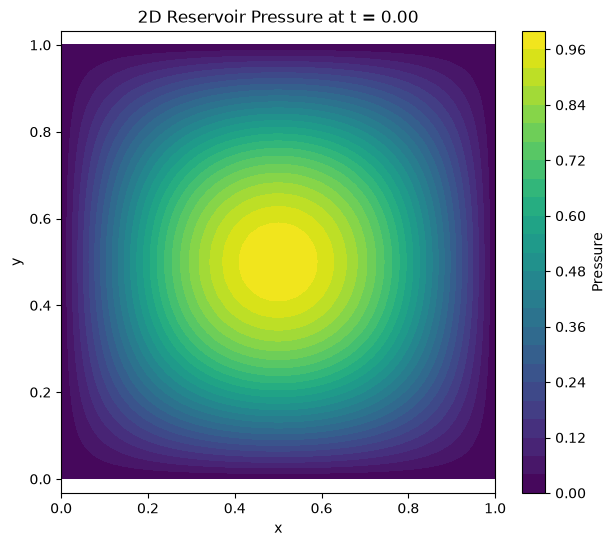

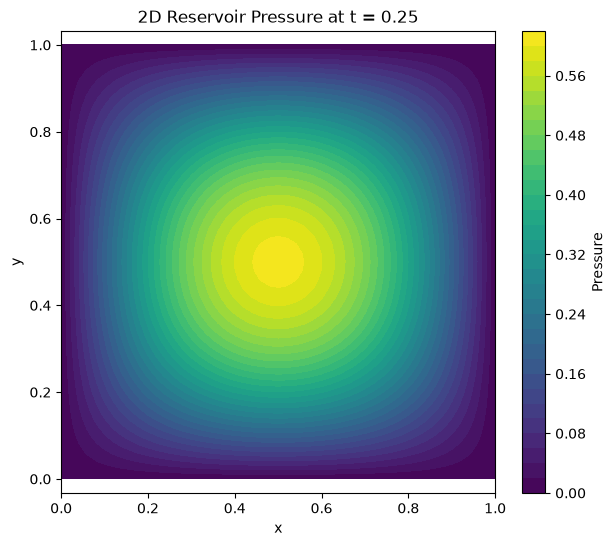

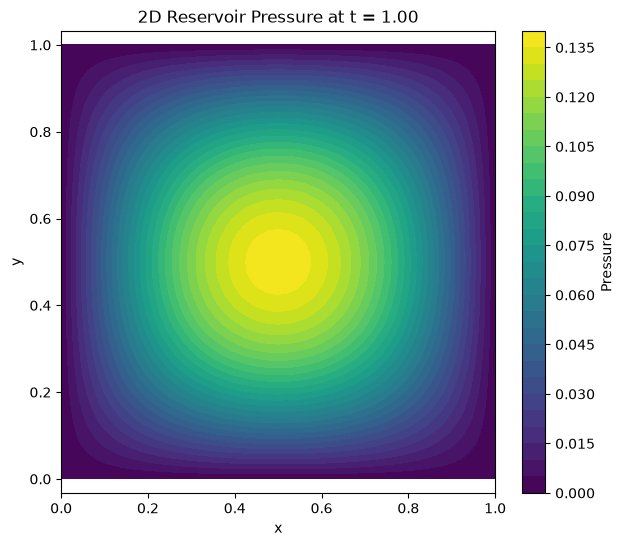

In [13]:
# ============================================================
# Save 2D Pressure Diffusion Results
# ============================================================

time_indices = [
    0,
    int(0.25 / dt),
    Nt - 1
]

for index in time_indices:

    plt.figure(figsize=(7, 6))

    plt.contourf(
        X,
        Y,
        pressure[index, :, :],
        levels=30
    )

    plt.colorbar(label="Pressure")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"2D Reservoir Pressure at t = {time[index]:.2f}")
    plt.axis("equal")

    filename = f"../results/2d_pressure_t_{time[index]:.2f}.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [30]:
# ============================================================
# Create the 2D Reference Dataset
# ============================================================

# Create 3D coordinate grids
X_data, Y_data, T_data = np.meshgrid(
    x,
    y,
    time,
    indexing="xy"
)

# Flatten everything into columns
x_flat = X_data.flatten()
y_flat = Y_data.flatten()
time_flat = T_data.flatten()
pressure_flat = pressure.flatten()

# Create the dataframe
reference_data_2d = pd.DataFrame({
    "x": x_flat,
    "y": y_flat,
    "time": time_flat,
    "pressure": pressure_flat
})

print("Reference dataset created.")
print("Dataset shape:", reference_data_2d.shape)

reference_data_2d.head()

Reference dataset created.
Dataset shape: (5204601, 4)


,x,y,time,pressure
0,0.0,0.0,0.0000,0.0
1,0.0,0.0,0.0005,0.0
2,0.0,0.0,0.0010,0.0
3,0.0,0.0,0.0015,0.0
4,0.0,0.0,0.0020,0.0


In [16]:
# ============================================================
# Create 2D Reference Dataset
# ============================================================
import os

# Create coordinate grids
X, Y = np.meshgrid(x, y, indexing="ij")

# Flatten the simulation results
x_data = np.tile(X.flatten(), Nt)
y_data = np.tile(Y.flatten(), Nt)

time_data = np.repeat(
    time,
    Nx * Ny
)

pressure_data = pressure.reshape(-1)

# Create DataFrame
reference_2d_df = pd.DataFrame({
    "x": x_data,
    "y": y_data,
    "time": time_data,
    "pressure": pressure_data
})

print("Reference dataset created.")
print("Dataset shape:", reference_2d_df.shape)
print(reference_2d_df.head())

Reference dataset created.
Dataset shape: (5204601, 4)
     x     y  time  pressure
0  0.0  0.00   0.0       0.0
1  0.0  0.02   0.0       0.0
2  0.0  0.04   0.0       0.0
3  0.0  0.06   0.0       0.0
4  0.0  0.08   0.0       0.0


In [17]:
# ============================================================
# Save 2D Reference Dataset
# ============================================================

data_folder = "../data"

os.makedirs(data_folder, exist_ok=True)

file_path = os.path.join(
    data_folder,
    "reference_2d_pressure.csv"
)

reference_2d_df.to_csv(
    file_path,
    index=False
)

print("2D reference dataset saved to:")
print(file_path)

2D reference dataset saved to:
../data\reference_2d_pressure.csv
